# Knowledge Factor Investigation 

In [1]:
%pwd

'/Users/lichao/Library/CloudStorage/OneDrive-Personal/MLD01_Article/MLD01e_Code'

In [2]:
%cd ..

/Users/lichao/Library/CloudStorage/OneDrive-Personal/MLD01_Article


/Users/lichao/opt/anaconda3/envs/ML/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Import PAckage

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier 

## Append Data

In [4]:
df_2016 = pd.read_parquet('Data/01_Napel2016.parquet')
df_2016['Year'] = 2016
df_2022 = pd.read_parquet('Data/01_Napel2022.parquet')
df_2022['Year'] = 2022

In [5]:
df_all = pd.concat([df_2016, df_2022], axis = 0)

In [6]:
df_all.shape

(11568, 351)

In [7]:
df_all = df_all.dropna(axis=1, how="any")

In [8]:
df_all.shape

(11568, 275)

In [9]:
df_all = df_all.set_index(['PSU', 'HHLD'])

In [10]:
df_all.columns

Index(['EcoBelt', 'Rural_Dummy', 'Respon_Female', 'Respon_Age', 'LivingYear',
       'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor', 'Edu_Master',
       'Edu_PhD',
       ...
       'SoilWaterConservationPast25', 'VisitClimateOfficePast25',
       'FoodConsumptionHabitPast25', 'OfffarmActiPast25',
       'NonFarmEmployPast25', 'FamilyMigrationPast25', 'RiskReductionPast25',
       'RoadImprovementPast25', 'CommunityPartipationPast25', 'Year'],
      dtype='object', length=273)

In [11]:
df_all["EcoBelt"] = df_all["EcoBelt"].astype("category")
df_all["EcoBelt"] = df_all["EcoBelt"].cat.codes

## Checking "HeardClimate_Dummy"

### Dataset building

In [12]:
for here in range(0, df_all.shape[1], 40):
    print(df_all.columns[0+here:40+here])

Index(['EcoBelt', 'Rural_Dummy', 'Respon_Female', 'Respon_Age', 'LivingYear',
       'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor', 'Edu_Master',
       'Edu_PhD', 'Edu_Literal', 'Edu_Illiterate', 'Female_Ratio', 'U18_Ratio',
       'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', 'Household_memberNum',
       'Own_Resid', 'Resid_Type', 'WaterS1', 'WaterS2', 'WaterS3',
       'CookFuelS1', 'CookFuelS2', 'CookFuelS3', 'LightEnergy', 'Toilet',
       'IncomeS1', 'IncomeS2', 'IncomeS3', 'Remittance_dummy', 'Have_AgriLand',
       'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy',
       'Mobile_dummy', 'Motorbike_dummy'],
      dtype='object')
Index(['Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
       'HouseHead_AgriExpYear', 'SavingMembership', 'RegularSaving',
       'OrgMembership', 'AgriSupport', 'Dist_Road', 'Dist_HealthCenter',
       'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 'FramMechan',
       'CropIncome', 'LivestockIncome', 'No

In [13]:
df_inuse = df_all[[ 'Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 
                   'Edu_Bachelor', 'Edu_Master', 'Edu_PhD', 'Edu_Literal', 'Edu_Illiterate', # S01
                   'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', # S02-1
                   'Own_Resid', 'Resid_Type', 'IncomeS1', 'IncomeS2', 'IncomeS3', 'Remittance_dummy', 'Have_AgriLand',
                   'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy',
                   'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
                   'HouseHead_AgriExpYear', 'SavingMembership', 'RegularSaving',
                   'OrgMembership', 'AgriSupport', 'Dist_Road', 'Dist_HealthCenter',
                   'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 'FramMechan',
                   'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome',
                   'TotalIncome', 'Year', 
                   'HeardClimate_Dummy'
                  ]]

## Hyper Tunining

In [62]:
y = df_inuse['HeardClimate_Dummy'].astype(int)
X = df_inuse.drop(columns=['HeardClimate_Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [63]:
clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    device = 'cuda'
)

In [64]:
param_distributions = {
    'n_estimators': [200, 500, 1_000, 2_000],
    'max_depth': [4,  8, 16],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 5, 10]
}

In [65]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=200,                 # increase for a more exhaustive search if you have time
    scoring='accuracy',
    return_train_score=True,
    cv=cv,
    verbose=3,
    refit=True,                # refit on entire data with best params
    random_state=42
)

search.fit(X, y)

Fitting 10 folds for each of 200 candidates, totalling 2000 fits
[CV 1/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.683) total time=   5.5s
[CV 2/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.717) total time=   5.1s
[CV 3/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.727) total time=   4.5s
[CV 4/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.722) total time=   4.7s
[CV 5/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.740) total time=   4.8s
[CV 6/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=

RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device='cuda',
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,...
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=42, ...),
                   n_iter=200,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 8, 16],
                                        'min_child_weight': [1, 2, 5, 10],
                                        'n_estimators': [200, 500, 1000, 2000],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, return_train_score=True, scoring='accuracy',
                   verbose=3)

In [66]:
# 7) Results
print("Best mean CV accuracy:", f"{search.best_score_:.4f}")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Best mean CV accuracy: 0.7379
Best params:
  subsample: 0.7
  n_estimators: 1000
  min_child_weight: 5
  max_depth: 16
  learning_rate: 0.01
  colsample_bytree: 0.8


In [67]:
cvres = pd.DataFrame(search.cv_results_)

In [69]:
cvres.to_parquet('Results/MLD01e_C01_KnowledgeFactorInvestigation.parquet')

In [71]:
cols = ['mean_test_score', 'std_test_score', 'rank_test_score'] + [c for c in cvres.columns if c.startswith('param_')]
cvres_sorted = cvres.sort_values('rank_test_score')[cols].head(10)

In [72]:
cvres_sorted

,mean_test_score,std_test_score,rank_test_score,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_colsample_bytree
79,0.737895,0.014421,1,0.7,1000,5,16,0.01,0.8
82,0.737723,0.014734,2,0.7,1000,1,16,0.01,0.9
176,0.737379,0.009796,3,0.8,2000,1,4,0.01,1.0
37,0.737204,0.010661,4,0.8,2000,2,4,0.01,0.7
105,0.736945,0.013279,5,1.0,200,2,16,0.05,0.8
54,0.736513,0.012367,6,0.8,2000,10,16,0.01,0.8
115,0.736427,0.012042,7,0.8,200,2,16,0.05,0.8
183,0.736253,0.012183,8,0.7,200,1,16,0.05,0.9
154,0.735734,0.012729,9,0.8,500,2,16,0.05,0.9
62,0.735476,0.015970,10,0.7,1000,2,16,0.01,0.9


## Test

### Fit Model

In [14]:
y = df_inuse['HeardClimate_Dummy']
X = df_inuse.drop(columns = ['HeardClimate_Dummy'])

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

In [16]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [17]:
clf = XGBClassifier(
    n_estimators=1_000,
    max_depth=16,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",          # fast and memory-efficient
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

In [18]:
clf.fit(
    X_train, y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=16,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [19]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
try:
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
except ValueError:
    # If y is not binary or only one class present in y_test
    pass

Accuracy: 0.7458945548833189
ROC-AUC: 0.8206155504913132


In [20]:
print("\nClassification report:\n", classification_report(y_test, y_pred))


Classification report:
               precision    recall  f1-score   support

           0       0.77      0.80      0.78       669
           1       0.71      0.67      0.69       488

    accuracy                           0.75      1157
   macro avg       0.74      0.74      0.74      1157
weighted avg       0.74      0.75      0.74      1157



Confusion Matrix:
 [[534 135]
 [159 329]]


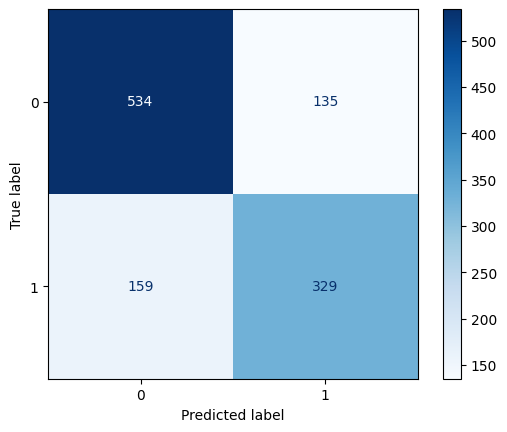

In [21]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

# Optional: nice plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap="Blues")

### Importance

In [22]:
# Get importance values
importances = pd.Series(clf.feature_importances_, index=X_train.columns)

# Sort descending
importances = importances.sort_values(ascending=False)

print(importances.head(20))   # Top 20 important features

Edu_Illiterate     0.172922
PC_dummy           0.085624
Year               0.051481
Edu_Literal        0.030364
Mobile_dummy       0.026443
Edu_Certificate    0.026146
Edu12_Ratio        0.023639
Edu_Bachelor       0.021487
TV_dummy           0.020701
Phone_dummy        0.019054
Edu_Master         0.017629
Respon_Female      0.017262
Edu_UnderSLC       0.017165
Dist_Road          0.016593
CropIncome         0.016176
AgriSupport        0.015459
Radio_dummy        0.014939
Refrige_dummy      0.014838
IncomeS3           0.014657
Net_dummy          0.014407
dtype: float32


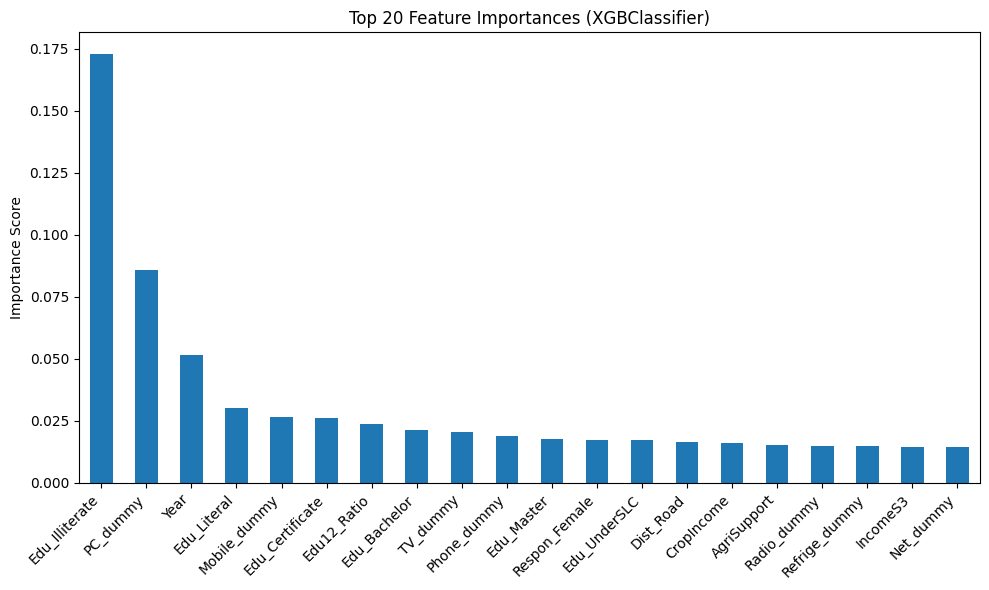

In [23]:
plt.figure(figsize=(10,6))
importances.head(20).plot(kind="bar")
plt.title("Top 20 Feature Importances (XGBClassifier)")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [35]:
importances.head(20).index

Index(['Edu_Illiterate', 'PC_dummy', 'Year', 'Edu_Literal', 'Mobile_dummy',
       'Edu_Certificate', 'Edu12_Ratio', 'Edu_Bachelor', 'TV_dummy',
       'Phone_dummy', 'Edu_Master', 'Respon_Female', 'Edu_UnderSLC',
       'Dist_Road', 'CropIncome', 'AgriSupport', 'Radio_dummy',
       'Refrige_dummy', 'IncomeS3', 'Net_dummy'],
      dtype='object')

### Checking Impacts

Edu_Illiterate, -0.1893


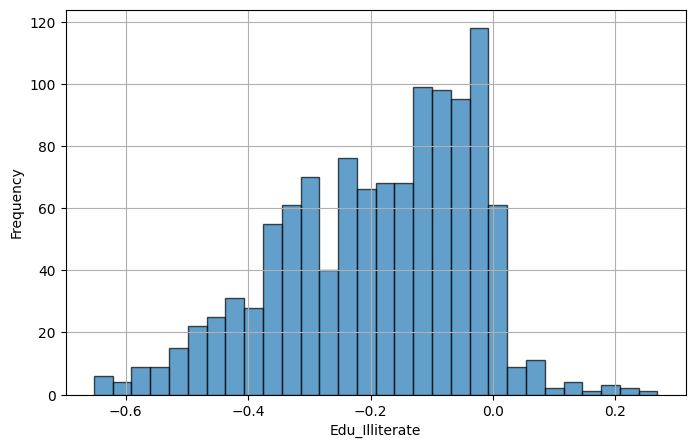

PC_dummy, 0.0633


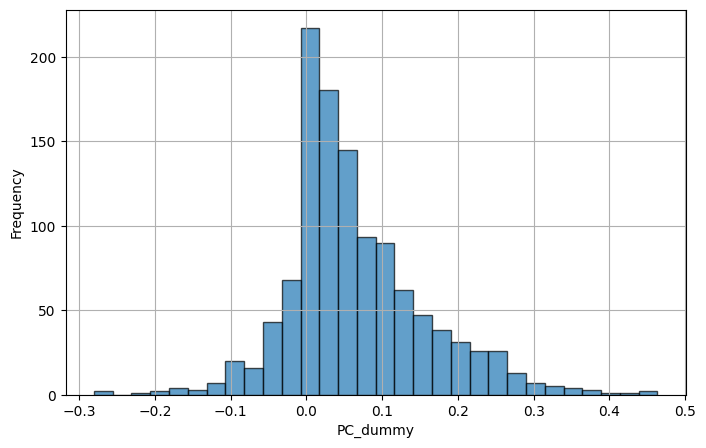

Edu_Literal, -0.0526


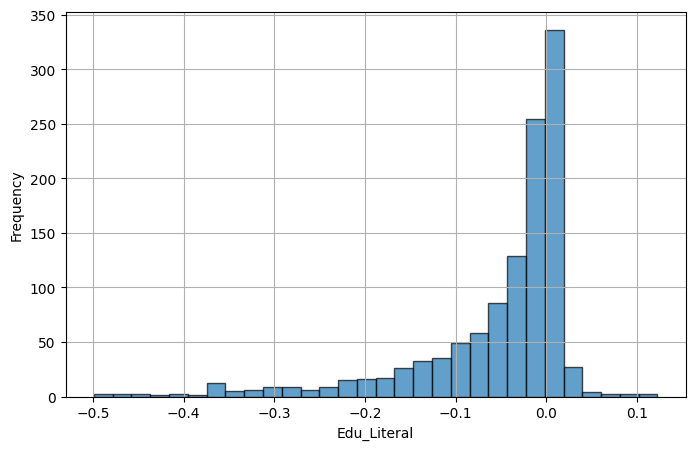

Mobile_dummy, -0.0494


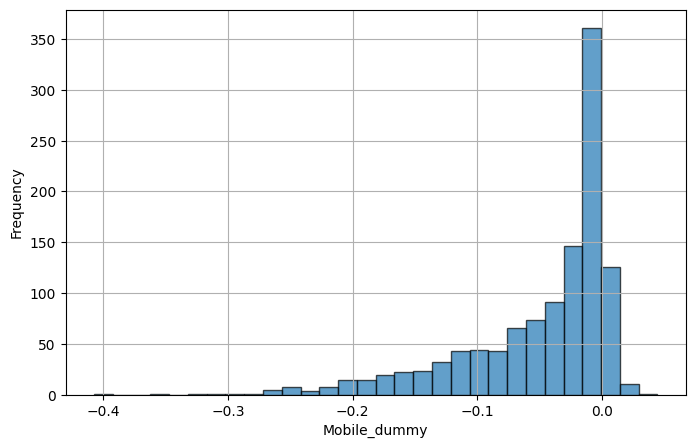

Edu_Certificate, 0.0714


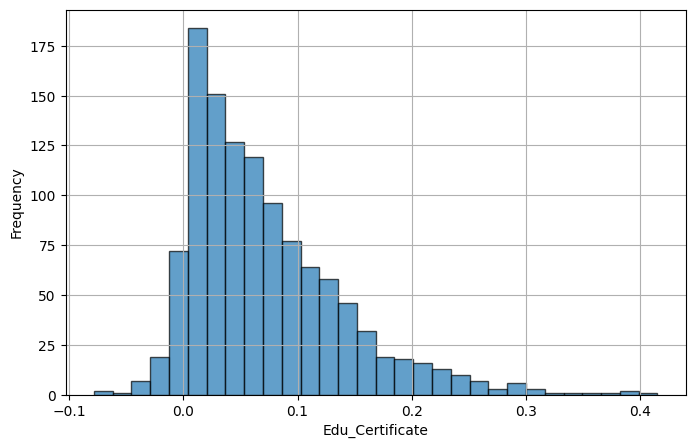

Edu_Bachelor, 0.0562


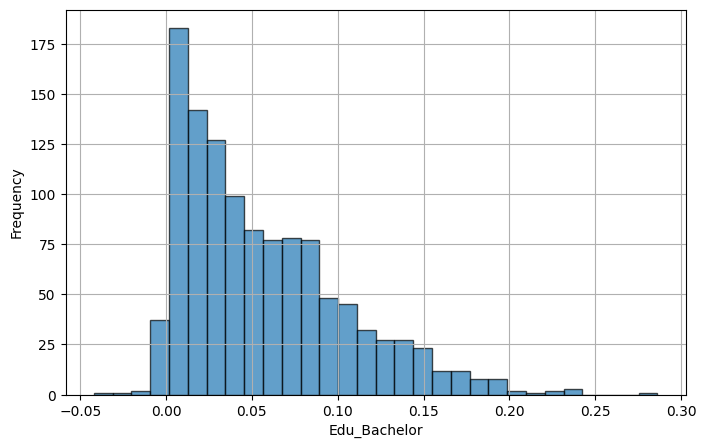

TV_dummy, 0.0357


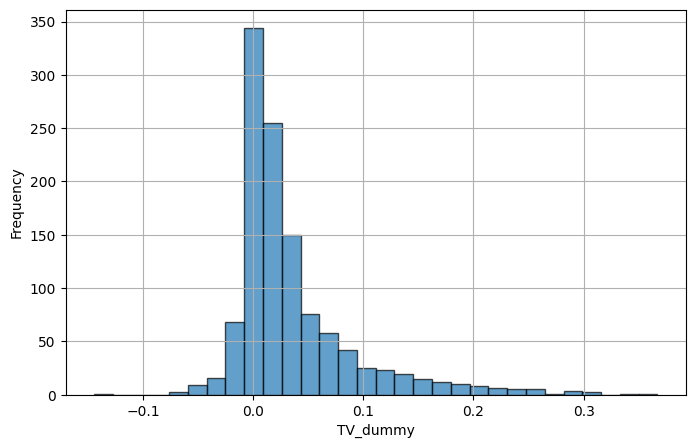

Phone_dummy, 0.0246


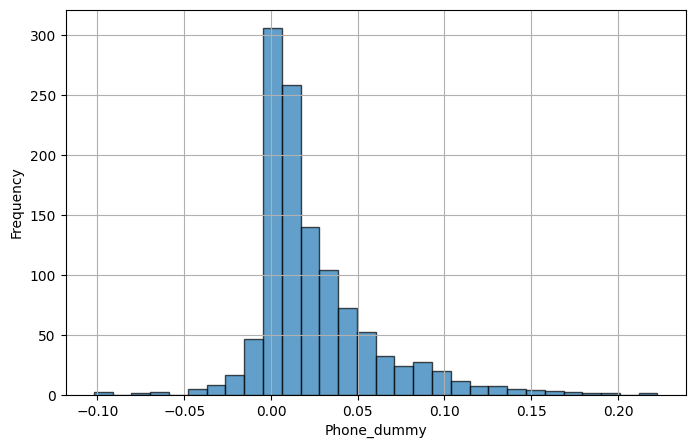

Edu_Master, 0.0618


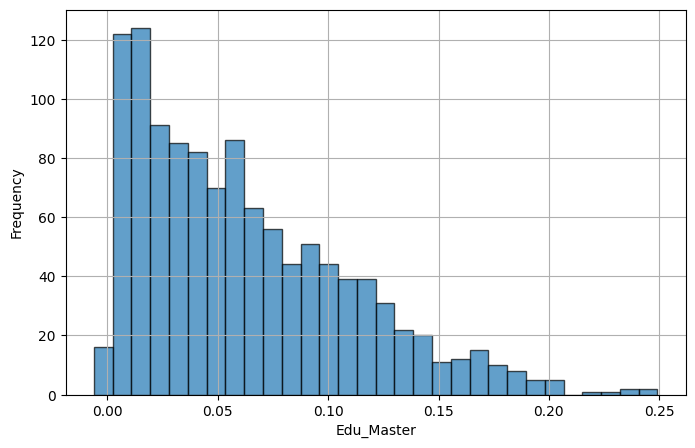

Respon_Female, -0.0857


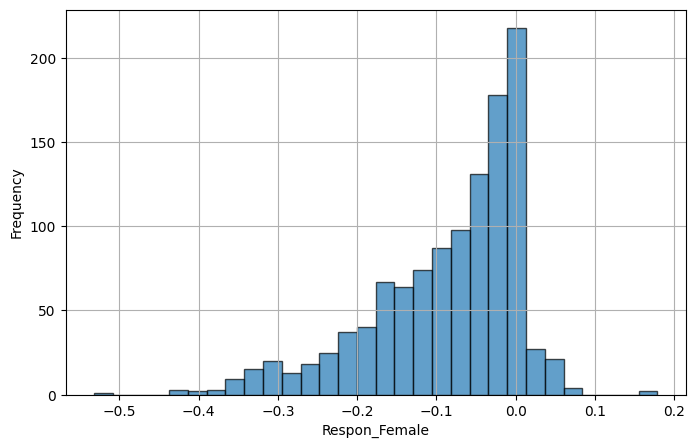

Edu_UnderSLC, 0.0250


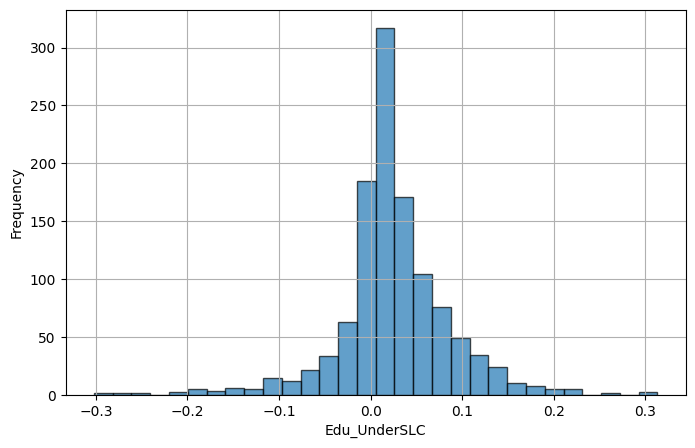

AgriSupport, 0.0335


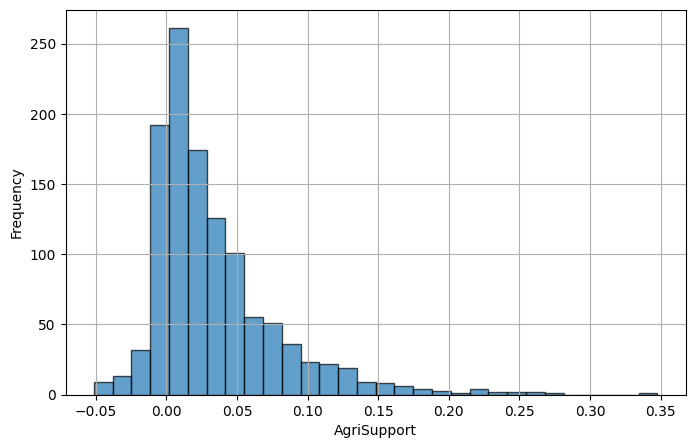

Radio_dummy, 0.0354


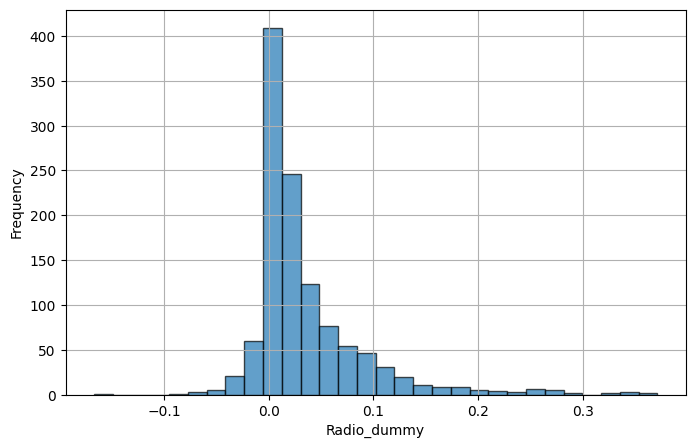

Refrige_dummy, 0.0119


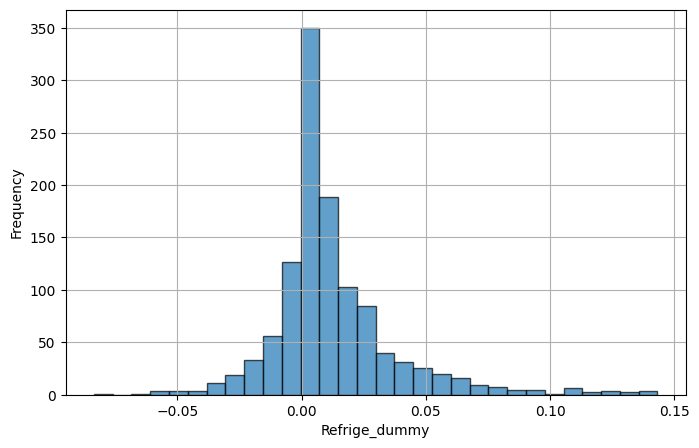

Net_dummy, 0.0148


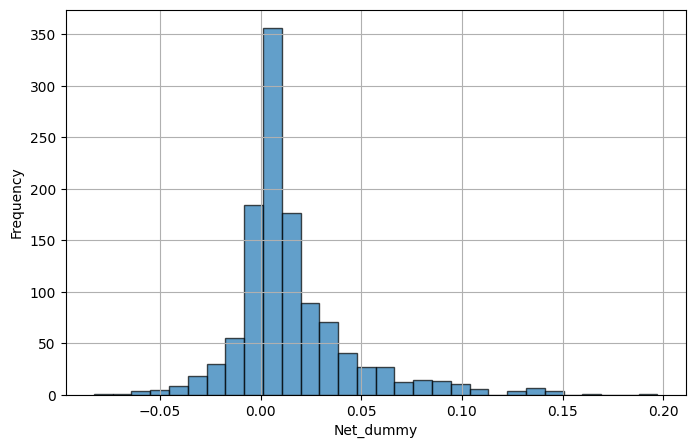

In [36]:
for name in ['Edu_Illiterate', 'PC_dummy', 'Edu_Literal', 'Mobile_dummy',
       'Edu_Certificate', 'Edu_Bachelor', 'TV_dummy',
       'Phone_dummy', 'Edu_Master', 'Respon_Female', 'Edu_UnderSLC',
       'AgriSupport', 'Radio_dummy', 'Refrige_dummy', 'Net_dummy']:
    X_test_tide = X_test.copy()
    X_test_tide[name] = 1
    y_proba_true = clf.predict_proba(X_test_tide)[:, 1]

    X_test_tide = X_test.copy()
    X_test_tide[name] = 0
    y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    

    y_proba_diff = y_proba_true - y_proba_false
    print(f"{name}, {np.mean(y_proba_diff):.04f}")

    plt.figure(figsize=(8,5))
    plt.hist(y_proba_diff, bins=30, edgecolor="black", alpha=0.7)
    plt.xlabel(name)
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

In [31]:
y_proba_diff

array([-0.1053277 , -0.21896806, -0.23846263, ...,  0.21430153,
       -0.08145863, -0.41204885], dtype=float32)